In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [11]:
df = pd.read_csv('Housing.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


sqft_living: 191.81
sqft_lot: -0.28
sqft_above: 88.17
sqft_basement: 103.64
intercept: -42064.24
Training Score (R^2): 0.49544386159379417
Testing Score (R^2): 0.4892993704463007


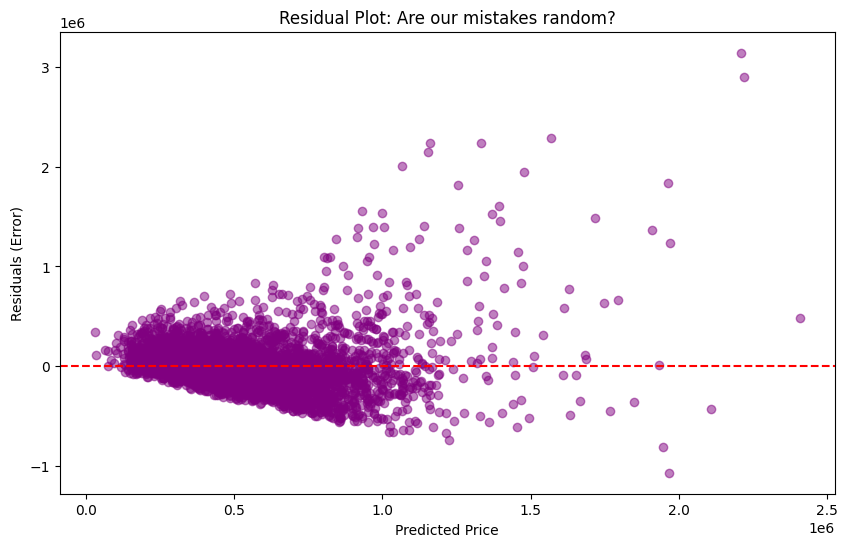

In [36]:

features = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement'] # I'm trying to capture all area-related X-coordinate data since that is (i believe) the most likely to increase price
X = df[features]  # This is now a 2D table, not a single line 
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)



model = LinearRegression()
model.fit(X_train, y_train)

for feature, weight in zip(features, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"intercept: {model.intercept_:.2f}")

print("Training Score (R^2):", model.score(X_train, y_train))
print("Testing Score (R^2):", model.score(X_test, y_test))

# Here our training and testing score are identical (R^2 = 0.5). This is great news because it tells us that our model can act as reliably with new data as it did with the training. We are neither underfitting nor overfitting.
# This is still not an optimal solution as our model is still too simple (high bias)\

y_pred = model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--') # The "Perfect" line
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot: Are our mistakes random?')
plt.show()